In [1]:
# Slide 10
# Image Data
# https://www.imageprocessingplace.com/DIP-3E/dip3e_book_images_downloads.htm

import cv2
import numpy as np
import matplotlib.pyplot as plt

10.1 – Histogram-based Global Thresholding Analysis (Otsu's Method from Scratch)

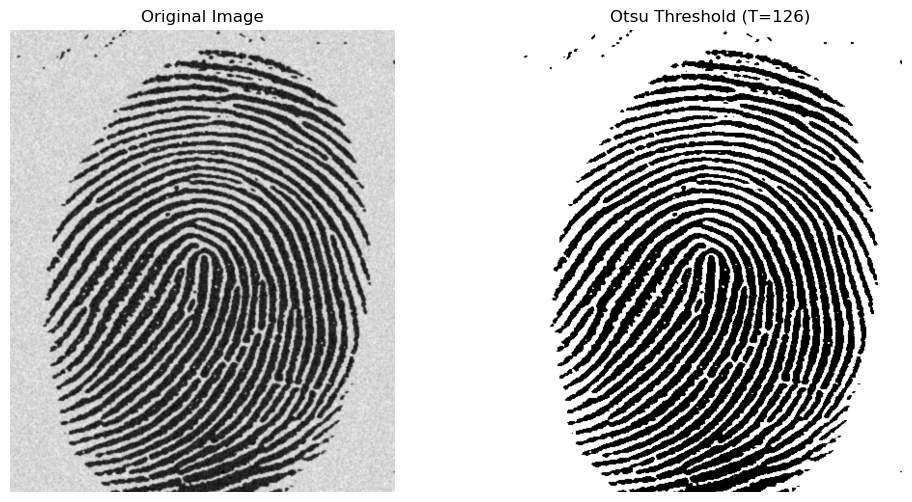

In [2]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1038(a)(noisy_fingerprint).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Calculate histogram and normalized probabilities
hist = np.zeros(256)
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        hist[img[i, j]] += 1
probs = hist / (img.shape[0] * img.shape[1])

# Otsu's algorithm to find optimal threshold T
max_variance = 0
best_T = 0

for T in range(1, 256):
    w0 = np.sum(probs[:T])
    w1 = np.sum(probs[T:])
    if w0 == 0 or w1 == 0: continue

    u0 = np.sum(np.arange(T) * probs[:T]) / w0
    u1 = np.sum(np.arange(T, 256) * probs[T:]) / w1

    # Inter-class variance
    sigma_b_squared = w0 * w1 * ((u0 - u1) ** 2)

    if sigma_b_squared > max_variance:
        max_variance = sigma_b_squared
        best_T = T

# Apply thresholding
binary_img = np.zeros_like(img)
binary_img[img > best_T] = 255

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original Image'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(binary_img, cmap='gray'); plt.title(f'Otsu Threshold (T={best_T})'); plt.axis('off')
plt.show()

10.2 – Thresholding under Uneven Illumination (Variable/Local Thresholding)

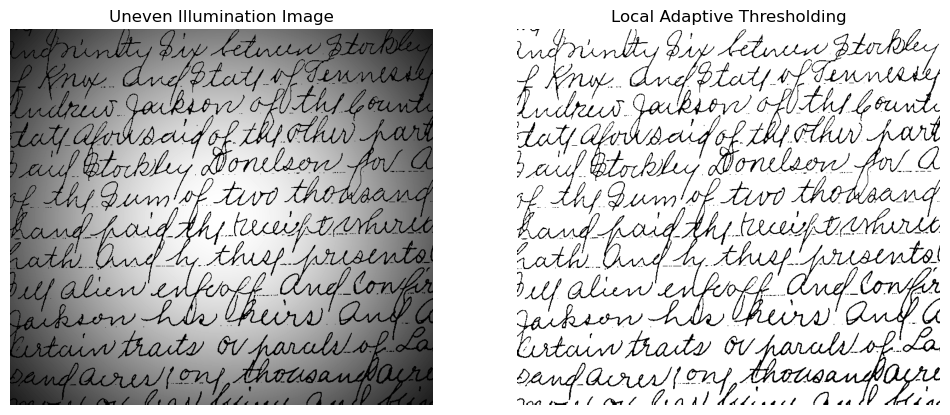

In [3]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1049(a)(spot_shaded_text_image).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Local mean thresholding using moving average (simulated by box filter)
k_size = 41
mean_img = cv2.blur(img, (k_size, k_size))
# If pixel is > local mean - constant, set to white
const = 15
binary_img = np.where(img > (mean_img - const), 255, 0).astype(np.uint8)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Uneven Illumination Image'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(binary_img, cmap='gray'); plt.title('Local Adaptive Thresholding'); plt.axis('off')
plt.show()

10.3 – Thresholding based on Boundary Pixels (Using Gradient Masking)

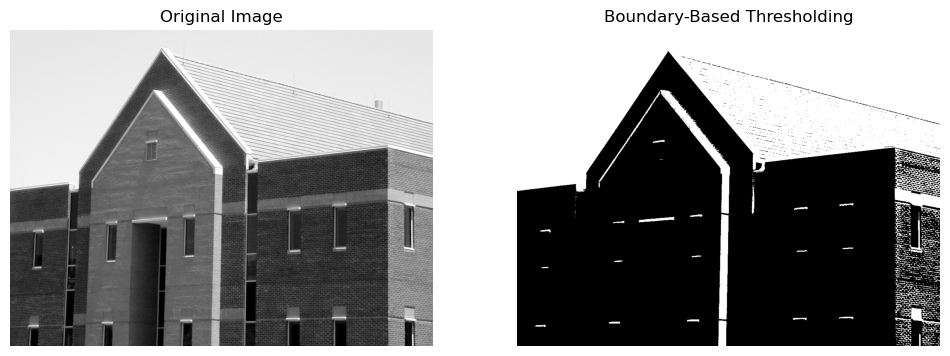

In [4]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1016(a)(building_original).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Compute gradient magnitude (Sobel)
gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
mag = np.sqrt(gx**2 + gy**2)

# Create mask for pixels with high gradient (boundary pixels)
T_grad = np.percentile(mag, 90) # Top 10% highest gradients
mask = mag > T_grad

# Compute threshold from the mean of masked pixels
T_boundary = np.mean(img[mask])
binary_img = (img > T_boundary).astype(np.uint8) * 255

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original Image'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(binary_img, cmap='gray'); plt.title('Boundary-Based Thresholding'); plt.axis('off')
plt.show()

10.4 – Gradient-based Boundary Detection for Thresholding (Mask Visualization)

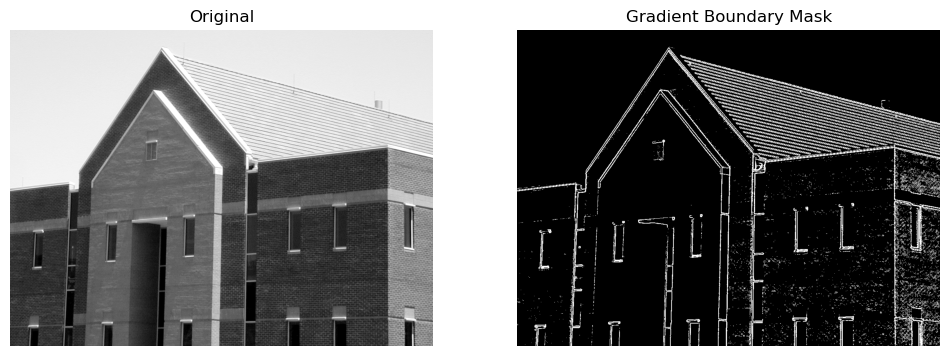

In [5]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1016(a)(building_original).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Gradient masking logic
gx = cv2.Sobel(img, cv2.CV_64F, 1, 0)
gy = cv2.Sobel(img, cv2.CV_64F, 0, 1)
mag = np.abs(gx) + np.abs(gy)
boundary_mask = (mag > (mag.max() * 0.2)).astype(np.uint8) * 255

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(boundary_mask, cmap='gray'); plt.title('Gradient Boundary Mask'); plt.axis('off')
plt.show()

10.5 – Laplacian-based Region Side Detection

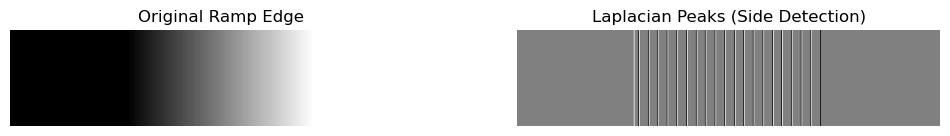

In [6]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1008(b)(ramp edge).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Laplacian operator
lap_mask = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])
laplacian = cv2.filter2D(img.astype(float), -1, lap_mask)

# Detect sides (positive vs negative peaks around edge)
positive_side = (laplacian > 0.5).astype(np.uint8) * 255
negative_side = (laplacian < -0.5).astype(np.uint8) * 255

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original Ramp Edge'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(laplacian, cmap='gray'); plt.title('Laplacian Peaks (Side Detection)'); plt.axis('off')
plt.show()

10.6 – Three-level Image Formation (0, +, − Labeling)

[ WARN:0@3.145] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@3.145] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@3.145] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@3.145] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@3.145] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@3.145] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@3.145] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@3.145] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

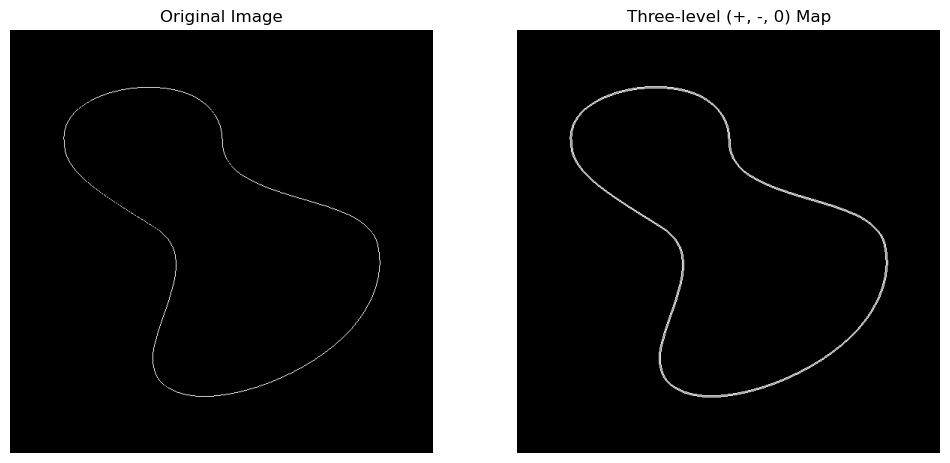

In [7]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1001(b)(edge_image).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

laplacian = cv2.Laplacian(img, cv2.CV_64F)
threshold = laplacian.std() * 0.5

# Labels: 0 (background/flat), 255 (positive side), 128 (negative side)
three_level = np.zeros_like(img)
three_level[laplacian > threshold] = 255
three_level[laplacian < -threshold] = 128

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original Image'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(three_level, cmap='gray'); plt.title('Three-level (+, -, 0) Map'); plt.axis('off')
plt.show()

10.7 – Binary Image Generation from Boundary Transitions

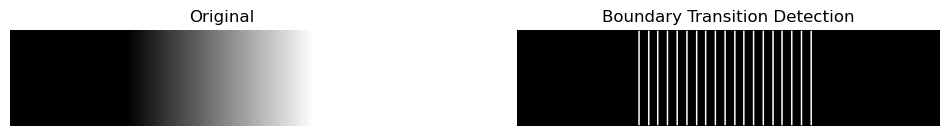

In [8]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1008(b)(ramp edge).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Logic to identify the transition region from Laplacian signs
laplacian = cv2.Laplacian(img, cv2.CV_64F)
binary_transition = np.zeros_like(img)
# Simple zero-crossing detection approximation
for i in range(1, img.shape[0]-1):
    for j in range(1, img.shape[1]-1):
        patch = laplacian[i-1:i+2, j-1:j+2]
        if (patch.min() < 0 and patch.max() > 0):
            binary_transition[i, j] = 255

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(binary_transition, cmap='gray'); plt.title('Boundary Transition Detection'); plt.axis('off')
plt.show()

10.8 – Seed-based Region Growing Algorithm

[ WARN:0@3.897] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@3.897] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@3.897] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@3.897] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@3.897] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@3.897] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@3.897] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@3.897] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

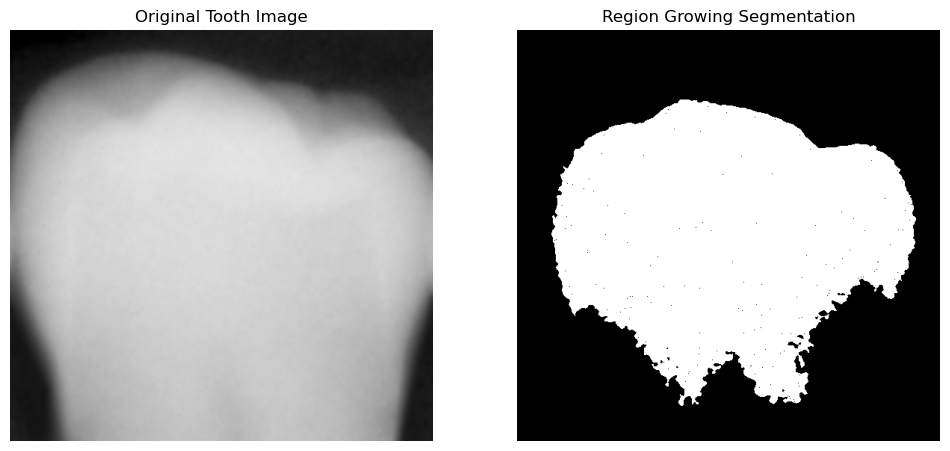

In [9]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1030(a)(tooth).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Manual seed and threshold
seed = (200, 200)
threshold = 20
rows, cols = img.shape
out = np.zeros_like(img)
visited = np.zeros_like(img, dtype=bool)

# Region growing using a stack
stack = [seed]
seed_val = img[seed]

while stack:
    x, y = stack.pop()
    if visited[x, y]: continue
    visited[x, y] = True

    if abs(int(img[x, y]) - int(seed_val)) <= threshold:
        out[x, y] = 255
        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
            nx, ny = x+dx, y+dy
            if 0 <= nx < rows and 0 <= ny < cols:
                stack.append((nx, ny))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original Tooth Image'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(out, cmap='gray'); plt.title('Region Growing Segmentation'); plt.axis('off')
plt.show()

10.9 – Region Splitting Algorithm (Homogeneity Test)

[ WARN:0@4.997] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


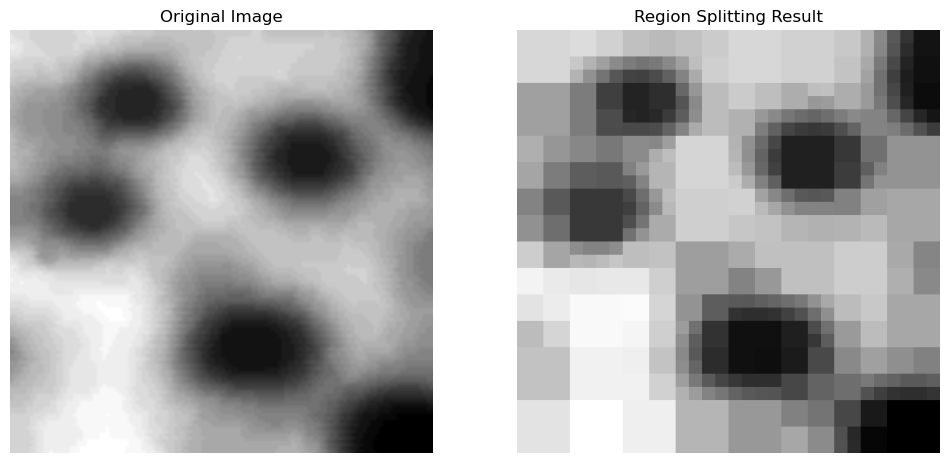

In [10]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1056(a)(blob_original).tif'
img = cv2.resize(cv2.imread(image_path, cv2.IMREAD_GRAYSCALE), (512, 512))

def is_homogeneous(region, threshold=10):
    return np.std(region) <= threshold

def recursive_split(img_part, x, y, size, out_img):
    if is_homogeneous(img_part) or size <= 4:
        out_img[x:x+size, y:y+size] = np.mean(img_part)
    else:
        half = size // 2
        recursive_split(img_part[:half, :half], x, y, half, out_img)
        recursive_split(img_part[:half, half:], x, y+half, half, out_img)
        recursive_split(img_part[half:, :half], x+half, y, half, out_img)
        recursive_split(img_part[half:, half:], x+half, y+half, half, out_img)

out = np.zeros_like(img)
recursive_split(img, 0, 0, 512, out)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original Image'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(out, cmap='gray'); plt.title('Region Splitting Result'); plt.axis('off')
plt.show()

10.10 – Quadtree-based Image Splitting (Visualization of Grid)

[ WARN:0@5.314] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


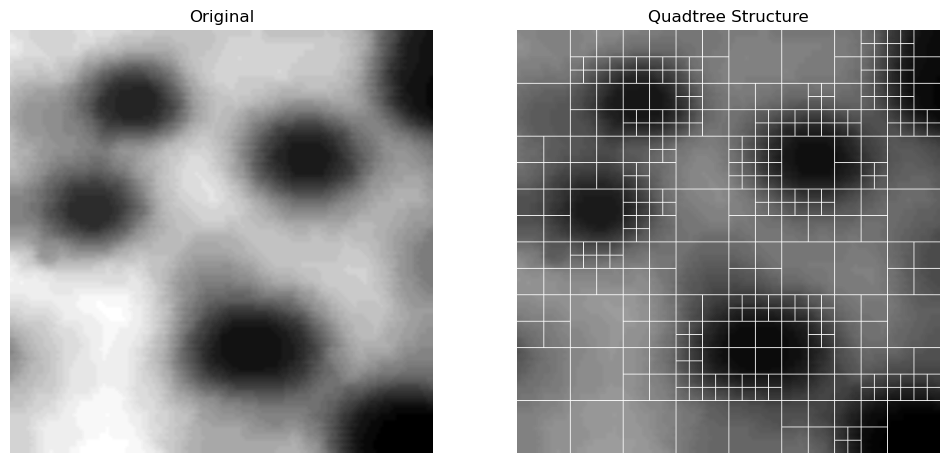

In [11]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1056(a)(blob_original).tif'
img = cv2.resize(cv2.imread(image_path, cv2.IMREAD_GRAYSCALE), (512, 512))

grid_img = img.copy()

def draw_quadtree(x, y, size, threshold=10):
    region = img[x:x+size, y:y+size]
    if np.std(region) > threshold and size > 16:
        half = size // 2
        cv2.line(grid_img, (y+half, x), (y+half, x+size), 255, 1)
        cv2.line(grid_img, (y, x+half), (y+size, x+half), 255, 1)
        draw_quadtree(x, y, half)
        draw_quadtree(x, y+half, half)
        draw_quadtree(x+half, y, half)
        draw_quadtree(x+half, y+half, half)

draw_quadtree(0, 0, 512)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(grid_img, cmap='gray'); plt.title('Quadtree Structure'); plt.axis('off')
plt.show()

10.11 – Region Merging Algorithm (Basic concept)

[ WARN:0@5.668] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


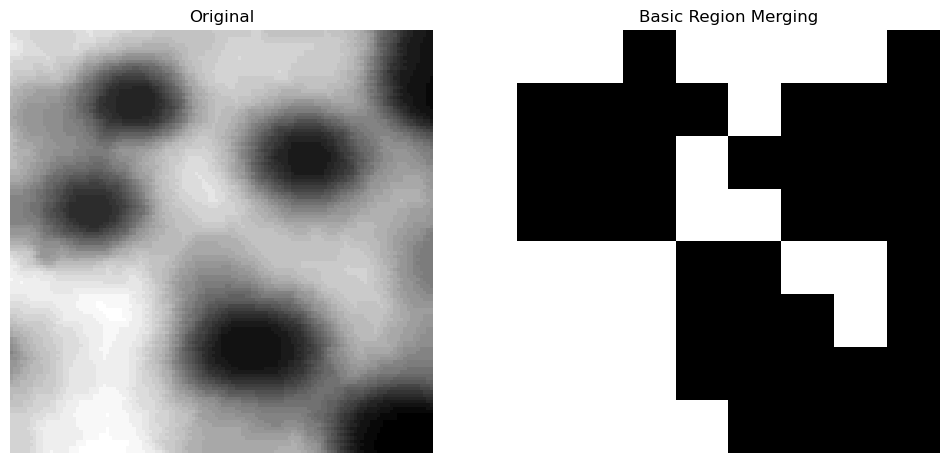

In [12]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1056(a)(blob_original).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# To demonstrate merging, we start with over-segmented blocks and merge similar ones
h, w = img.shape
merged = np.zeros_like(img)
block_size = 16

for i in range(0, h, block_size):
    for j in range(0, w, block_size):
        block = img[i:i+block_size, j:j+block_size]
        avg = np.mean(block)
        # Simple merging logic: if mean is below threshold, label as background
        merged[i:i+block_size, j:j+block_size] = 255 if avg > 128 else 0

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(merged, cmap='gray'); plt.title('Basic Region Merging'); plt.axis('off')
plt.show()

10.12 – Split-and-Merge Segmentation Approach

[ WARN:0@5.869] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


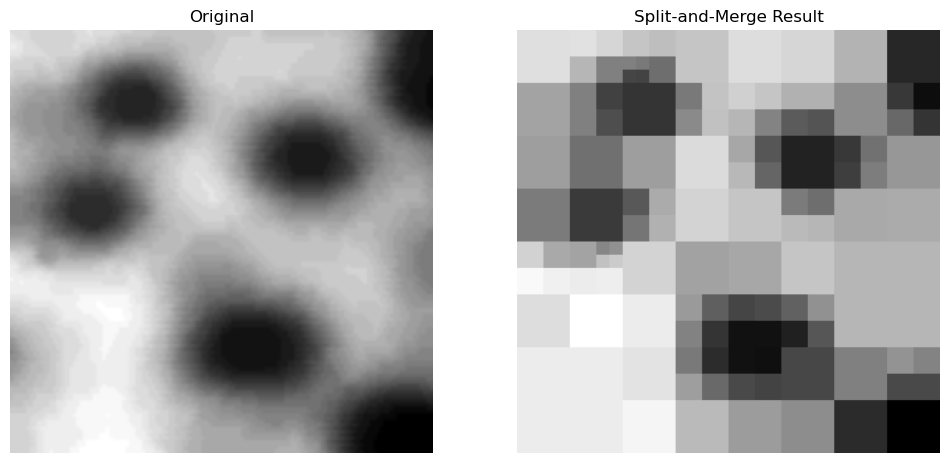

In [13]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1056(a)(blob_original).tif'
img = cv2.resize(cv2.imread(image_path, cv2.IMREAD_GRAYSCALE), (256, 256))

# Recursive split followed by a global grouping (simulating merge)
def split_merge(img_part):
    if np.std(img_part) < 15:
        return np.full(img_part.shape, np.mean(img_part))

    h, w = img_part.shape
    if h <= 4: return img_part

    half_h, half_w = h // 2, w // 2
    top_left = split_merge(img_part[:half_h, :half_w])
    top_right = split_merge(img_part[:half_h, half_w:])
    bottom_left = split_merge(img_part[half_h:, :half_w])
    bottom_right = split_merge(img_part[half_h:, half_w:])

    return np.block([[top_left, top_right], [bottom_left, bottom_right]])

result = split_merge(img).astype(np.uint8)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(result, cmap='gray'); plt.title('Split-and-Merge Result'); plt.axis('off')
plt.show()